# Pose Trajectory T-CFM Evaluation

Load a trained model checkpoint, generate trajectories conditioned on context vectors, and visualize results.

In [1]:
import os, sys
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

# make sure project root is on path
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), ""))
sys.path.insert(0, os.getcwd())
os.chdir(os.path.expanduser("~/PhysicalAI_flowmatching"))

import diffuser.utils as utils

## 1. Configuration

Set the checkpoint path and device. Update `CHECKPOINT_PATH` to point to your trained model.

In [2]:
# --- UPDATE THIS ---
CHECKPOINT_PATH = "logs/pose_trajectory_athit1D/cfm/H64_T100/20260415-2129/state_192000.pt"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DATA_PATH = "data/pose_traject_dataset_athit1D.npz"

HORIZON = 64        # padded horizon (must match training)
ORIGINAL_LEN = 50   # original trajectory length
N_SAMPLING_STEPS = 100  # Euler sampling steps for CFM

## 2. test datasetsetup

In [3]:
data = np.load(DATA_PATH) # load dataset (limit to 1M samples for memory)
df = pd.DataFrame(data['features'], columns=data['feature_names'])[:1000000] 
df['targets'] = [t for t in data['targets'][:1000000]]

# Context vector C (9-dim)
part_onehot = pd.get_dummies(df['part_enum'].astype(int), prefix='part').values
C = np.concatenate([
    df[['s_goal', 'qdot_init', 'v_const', 'accel']].values,
    part_onehot,
    df[['q_init']].values
], axis=1)

# Ground truth trajectories (x, y)
targets_raw = np.stack(df['targets'].values)
A_gt = targets_raw[:, :, 0:2]  # (N, 50, 2)

context_all = torch.tensor(C, dtype=torch.float32)
print(f"Dataset: {len(df)} samples, context_dim={C.shape[1]}, trajectory=({A_gt.shape[1]}, {A_gt.shape[2]})")

Dataset: 1000000 samples, context_dim=9, trajectory=(50, 1)


## 3. Build Model & Load Checkpoint

In [4]:
from diffuser.models.temporal_film import ConditionalUnet1D
from diffuser.models.cfm import CFM

observation_dim = 1  # we only predict x, 
action_dim = 0
context_dim = C.shape[1]  # 9

# Build model (must match training config)
model = ConditionalUnet1D(
    horizon=HORIZON,
    transition_dim=observation_dim + action_dim,
    lstm_in_dim=None,
    lstm_out_dim=None,
    global_cond_dim=context_dim,
    cond_dim=observation_dim,
    dim_mults=(1, 4, 8),
).to(DEVICE)

# Build diffusion wrapper
diffusion = CFM(
    model=model,
    horizon=HORIZON,
    observation_dim=observation_dim,
    action_dim=action_dim,
    n_timesteps=N_SAMPLING_STEPS,
    loss_type='l2',
    predict_epsilon=False,
).to(DEVICE)

# Load checkpoint
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
diffusion.load_state_dict(checkpoint['model'])
print(f"Loaded checkpoint from step {checkpoint['step']}")

Loaded checkpoint from step 195000


## 4. Sampling Helper

In [5]:
@torch.no_grad()
def sample_trajectories(diffusion, contexts, n_samples_per=1):
    """
    Generate trajectories for given context vectors.
    
    Args:
        diffusion: trained CFM model
        contexts: (B, 9) context tensor
        n_samples_per: how many samples to generate per context
    Returns:
        samples: (B * n_samples_per, ORIGINAL_LEN, 2) numpy array
        contexts_repeated: (B * n_samples_per, 9) numpy array
    """
    diffusion.eval()
    
    # repeat contexts for multiple samples
    ctx = contexts.repeat_interleave(n_samples_per, dim=0).to(DEVICE)
    batch_size = ctx.shape[0]
    
    global_cond = {'hideouts': ctx}
    cond = [(np.array([]), np.array([]))] * batch_size
    
    samples = diffusion.conditional_sample(global_cond, cond)  # (B*n, HORIZON, 2)
    samples = samples.cpu().numpy()
    
    # trim padding back to original 50 steps
    samples = samples[:, :ORIGINAL_LEN, :]
    contexts_out = ctx.cpu().numpy()
    
    return samples, contexts_out

print("Sampling helper ready.")

Sampling helper ready.


## 5. Generate Samples & Compute Metrics

Evaluated 200 contexts x 1 samples each
Metric                Mean        Std     Median
-----------------------------------------------
ADE (best)          0.0486     0.1384     0.0147
ADE (avg)           0.0486     0.1384     0.0147
FDE (best)          0.0217     0.0304     0.0146
FDE (avg)           0.0217     0.0304     0.0146


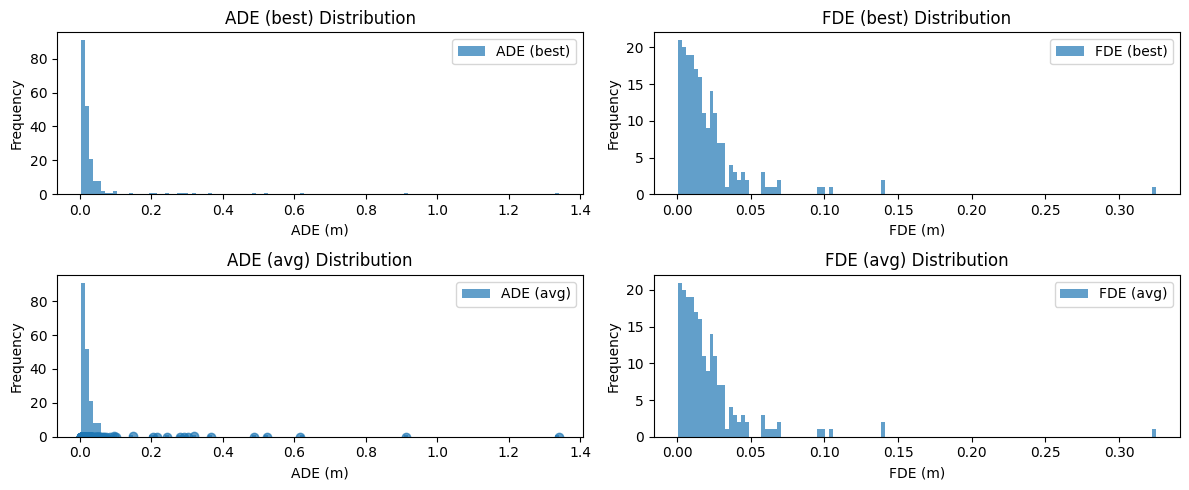

In [6]:
# Pick test samples to evaluate
N_EVAL = 200          # how many test contexts to use
# N_SAMPLES_PER = 5     # how many trajectories to sample per context
N_SAMPLES_PER = 1     # how many trajectories to sample per context

rng = np.random.default_rng(42)
eval_idx = rng.choice(len(context_all), N_EVAL, replace=False)

eval_contexts = context_all[eval_idx]
eval_gt = A_gt[eval_idx]  # (N_EVAL, 50, 2)

# Generate
samples, _ = sample_trajectories(diffusion, eval_contexts, n_samples_per=N_SAMPLES_PER)
samples = samples.reshape(N_EVAL, N_SAMPLES_PER, ORIGINAL_LEN, 1)

# --- ADE (Average Displacement Error) ---
# per-sample ADE: mean L2 distance over all timesteps
ade_per_sample = np.sqrt(((samples - eval_gt[:, None, :, :]) ** 2).sum(axis=-1)).mean(axis=-1)  # (N_EVAL, N_SAMPLES_PER)
ade_min = ade_per_sample.min(axis=1)    # best-of-N
ade_mean = ade_per_sample.mean(axis=1)  # average-of-N

# --- FDE (Final Displacement Error) ---
fde_per_sample = np.sqrt(((samples[:, :, -1, :] - eval_gt[:, None, -1, :]) ** 2).sum(axis=-1))  # (N_EVAL, N_SAMPLES_PER)
fde_min = fde_per_sample.min(axis=1)
fde_mean = fde_per_sample.mean(axis=1)

print(f"Evaluated {N_EVAL} contexts x {N_SAMPLES_PER} samples each")
print(f"{'Metric':<15} {'Mean':>10} {'Std':>10} {'Median':>10}")
print("-" * 47)
print(f"{'ADE (best)':<15} {ade_min.mean():>10.4f} {ade_min.std():>10.4f} {np.median(ade_min):>10.4f}")
print(f"{'ADE (avg)':<15} {ade_mean.mean():>10.4f} {ade_mean.std():>10.4f} {np.median(ade_mean):>10.4f}")
print(f"{'FDE (best)':<15} {fde_min.mean():>10.4f} {fde_min.std():>10.4f} {np.median(fde_min):>10.4f}")
print(f"{'FDE (avg)':<15} {fde_mean.mean():>10.4f} {fde_mean.std():>10.4f} {np.median(fde_mean):>10.4f}")

# plot distribution of errors
plt.figure(figsize=(12, 5))
plt.subplot(2, 2, 1)
plt.hist(ade_min, bins=120, alpha=0.7, label='ADE (best)')
# plt.hist(ade_mean, bins=120, alpha=0.7, label='ADE (avg)')
plt.xlabel('ADE (m)')
plt.ylabel('Frequency')
plt.title('ADE (best) Distribution')
plt.legend()

plt.subplot(2, 2, 2)
plt.hist(fde_min, bins=120, alpha=0.7, label='FDE (best)')
# plt.hist(fde_mean, bins=120, alpha=0.7, label='FDE (avg)')
plt.xlabel('FDE (m)')
plt.ylabel('Frequency')
plt.title('FDE (best) Distribution')
plt.legend()

plt.subplot(2, 2, 3)
plt.scatter(ade_min, fde_min, alpha=0.7)
# plt.hist(ade_min, bins=120, alpha=0.7, label='ADE (best)')
plt.hist(ade_mean, bins=120, alpha=0.7, label='ADE (avg)')
plt.xlabel('ADE (m)')
plt.ylabel('Frequency')
plt.title('ADE (avg) Distribution')
plt.legend()

plt.subplot(2, 2, 4)
# plt.hist(fde_min, bins=120, alpha=0.7, label='FDE (best)')
plt.hist(fde_mean, bins=120, alpha=0.7, label='FDE (avg)')
plt.xlabel('FDE (m)')
plt.ylabel('Frequency')
plt.title('FDE (avg) Distribution')
plt.legend()

plt.tight_layout()
plt.show()

## 6. Plot: Generated vs Ground Truth Trajectories

Each subplot shows one test context. The ground truth is in black, and generated samples are colored.

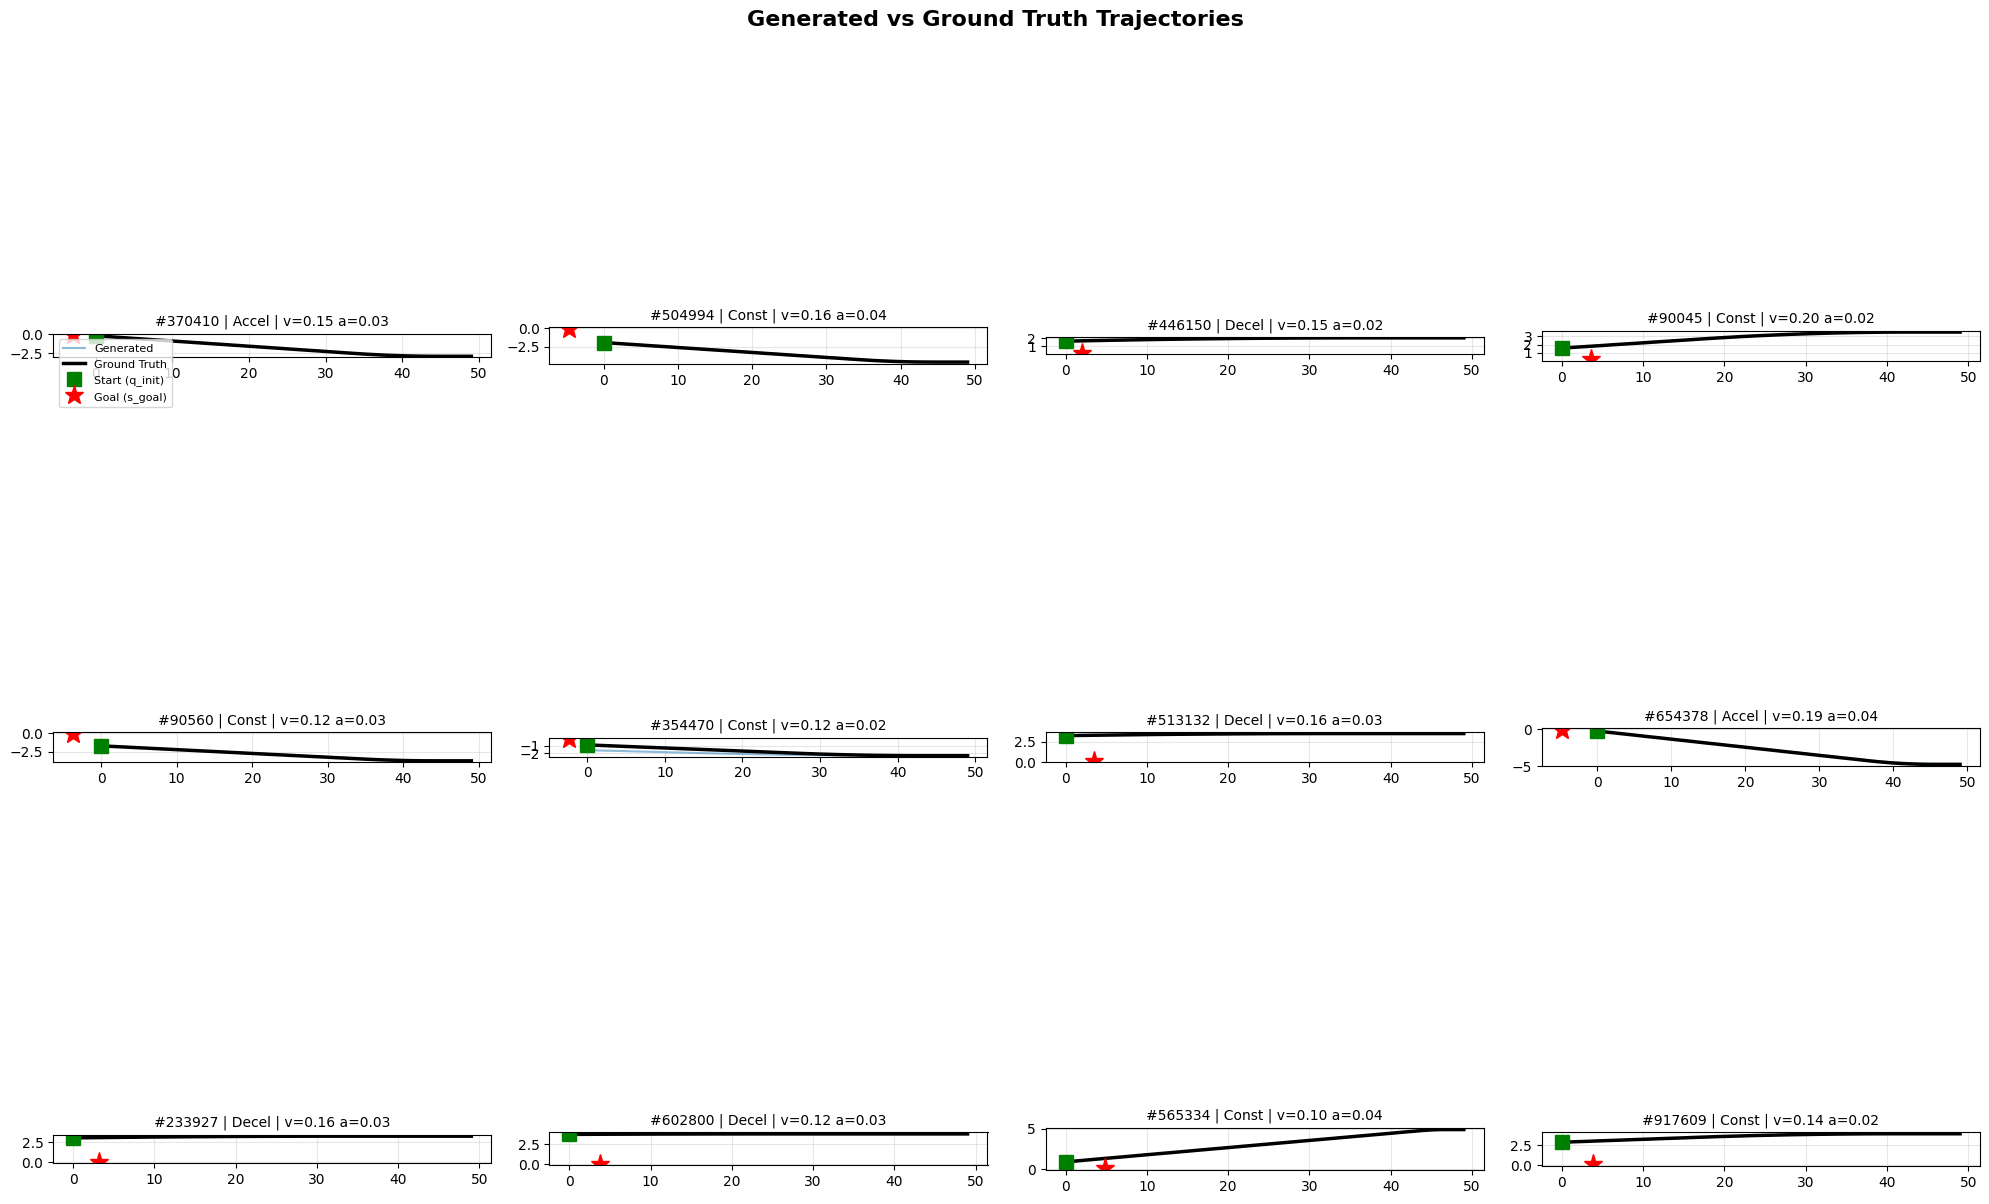

In [7]:
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()

for i, ax in enumerate(axes):
    gt = eval_gt[i]  # (50, 2)
    ctx = eval_contexts[i].numpy()
    
    # plot generated samples
    for s in range(N_SAMPLES_PER):
        traj = samples[i, s]  # (50, 2)
        ax.plot(traj[:, 0], alpha=0.5, linewidth=1.5, label='Generated' if s == 0 else None)
    
    # plot ground truth
    ax.plot(gt[:, 0], 'k-', linewidth=2.5, label='Ground Truth')
    
    # mark start and goal
    ax.plot(ctx[7], ctx[8], 'gs', markersize=10, label='Start (q_init)')
    ax.plot(ctx[0], ctx[1], 'r*', markersize=14, label='Goal (s_goal)')
    
    # part label
    part_names = ['Accel', 'Const', 'Decel']
    part_idx = np.argmax(ctx[4:7])
    ax.set_title(f"#{eval_idx[i]} | {part_names[part_idx]} | v={ctx[2]:.2f} a={ctx[3]:.2f}", fontsize=10)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    
    if i == 0:
        ax.legend(fontsize=8, loc='upper left')

plt.suptitle("Generated vs Ground Truth Trajectories", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 6b. Plot: x(t) and y(t) Over Time (GT vs Generated)

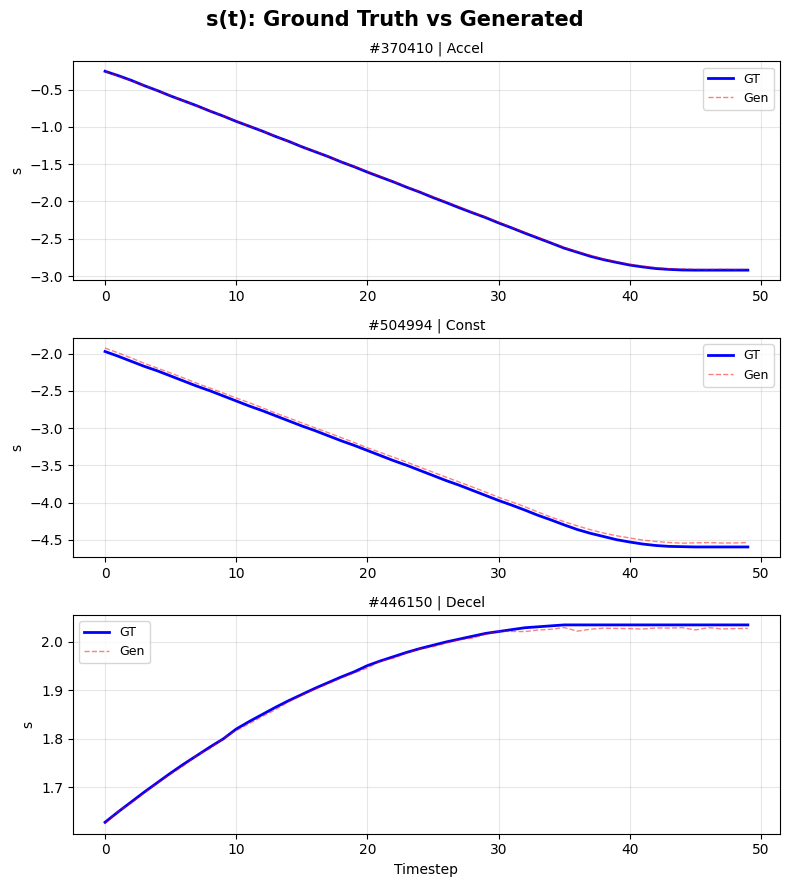

In [8]:
N_SHOW = 3  # number of examples to plot

# Regenerate samples from eval_contexts so this cell is self-contained
_plot_samples, _ = sample_trajectories(diffusion, eval_contexts[:N_SHOW], n_samples_per=N_SAMPLES_PER)
_plot_samples = _plot_samples.reshape(N_SHOW, N_SAMPLES_PER, ORIGINAL_LEN, 1)

fig, axes = plt.subplots(N_SHOW, 1, figsize=(8, 3 * N_SHOW))
if N_SHOW == 1:
    axes = [axes]
timesteps = np.arange(ORIGINAL_LEN)

for i in range(N_SHOW):
    gt = eval_gt[i]
    ax = axes[i]

    ax.plot(timesteps, gt[:, 0], 'b-', linewidth=2, label='GT')
    for s in range(N_SAMPLES_PER):
        ax.plot(timesteps, _plot_samples[i, s, :, 0], 'r--', linewidth=1, alpha=0.5,
                label='Gen' if s == 0 else None)
    ax.set_ylabel('s')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    if i == N_SHOW - 1:
        ax.set_xlabel('Timestep')

    ctx = eval_contexts[i].numpy()
    part_names = ['Accel', 'Const', 'Decel', 'Other']
    part_idx = np.argmax(ctx[4:8])
    ax.set_title(f'#{eval_idx[i]} | {part_names[part_idx]}', fontsize=10)

plt.suptitle('s(t): Ground Truth vs Generated', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Plot: ADE Over Prediction Horizon

Shows how error accumulates over time (per-timestep displacement error).

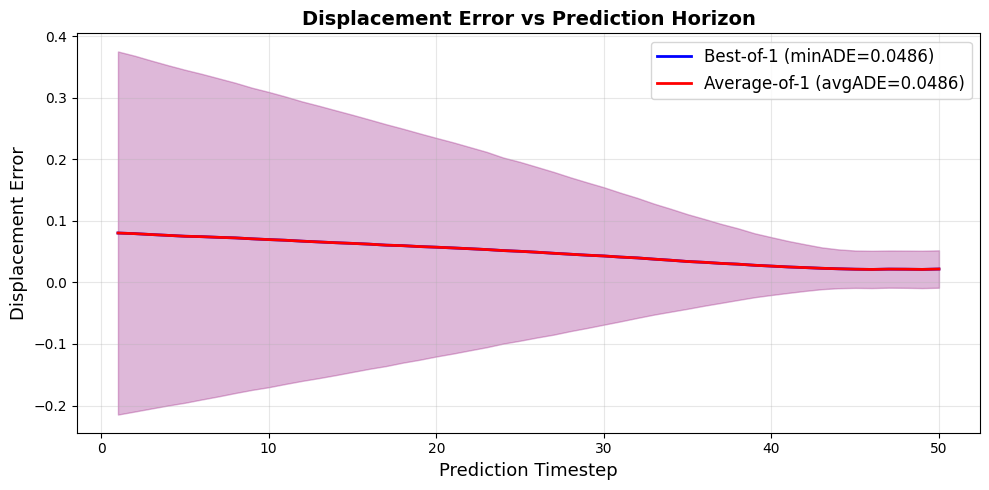

In [9]:
# Per-timestep displacement error: (N_EVAL, N_SAMPLES_PER, 50)
de_per_step = np.sqrt(((samples - eval_gt[:, None, :, :]) ** 2).sum(axis=-1))

# Best-of-N: pick the sample with lowest ADE for each context
best_idx = ade_per_sample.argmin(axis=1)  # (N_EVAL,)
de_best = de_per_step[np.arange(N_EVAL), best_idx, :]  # (N_EVAL, 50)Average
de_avg = de_per_step.mean(axis=1)  # (N_EVAL, 50)

fig, ax = plt.subplots(figsize=(10, 5))
timesteps = np.arange(1, ORIGINAL_LEN + 1)

mean_best = de_best.mean(axis=0)
std_best = de_best.std(axis=0)
mean_avg = de_avg.mean(axis=0)
std_avg = de_avg.std(axis=0)

ax.plot(timesteps, mean_best, 'b-', linewidth=2, label=f'Best-of-{N_SAMPLES_PER} (minADE={mean_best.mean():.4f})')
ax.fill_between(timesteps, mean_best - std_best, mean_best + std_best, alpha=0.15, color='b')

ax.plot(timesteps, mean_avg, 'r-', linewidth=2, label=f'Average-of-{N_SAMPLES_PER} (avgADE={mean_avg.mean():.4f})')
ax.fill_between(timesteps, mean_avg - std_avg, mean_avg + std_avg, alpha=0.15, color='r')

ax.set_xlabel("Prediction Timestep", fontsize=13)
ax.set_ylabel("Displacement Error", fontsize=13)
ax.set_title("Displacement Error vs Prediction Horizon", fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Plot: ADE Distribution & Per-Part Breakdown

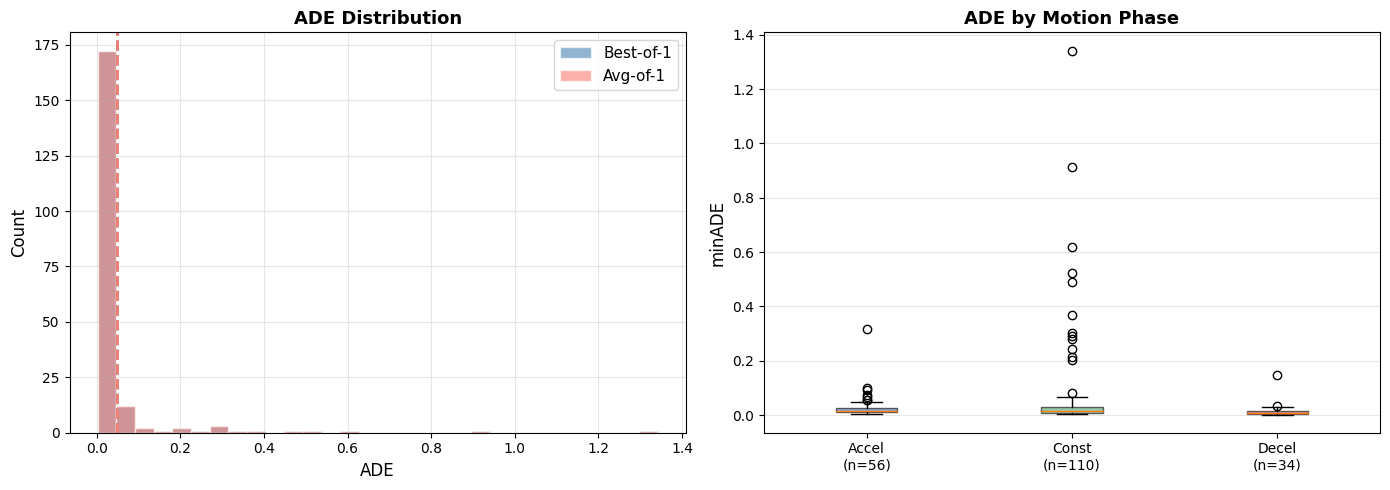

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: ADE histogram ---
ax1.hist(ade_min, bins=30, alpha=0.6, label=f'Best-of-{N_SAMPLES_PER}', color='steelblue', edgecolor='white')
ax1.hist(ade_mean, bins=30, alpha=0.6, label=f'Avg-of-{N_SAMPLES_PER}', color='salmon', edgecolor='white')
ax1.axvline(ade_min.mean(), color='steelblue', linestyle='--', linewidth=2)
ax1.axvline(ade_mean.mean(), color='salmon', linestyle='--', linewidth=2)
ax1.set_xlabel("ADE", fontsize=12)
ax1.set_ylabel("Count", fontsize=12)
ax1.set_title("ADE Distribution", fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# --- Right: ADE per motion part (Accel / Const / Decel) ---
part_names = ['Accel', 'Const', 'Decel']
eval_ctx_np = eval_contexts.numpy()
part_labels = np.argmax(eval_ctx_np[:, 4:7], axis=1)  # 0, 1, or 2

ade_by_part = {name: ade_min[part_labels == i] for i, name in enumerate(part_names)}
bp = ax2.boxplot(
    [ade_by_part[name] for name in part_names if len(ade_by_part[name]) > 0],
    labels=[f"{name}\n(n={len(ade_by_part[name])})" for name in part_names if len(ade_by_part[name]) > 0],
    patch_artist=True,
)
colors = ['#4C72B0', '#55A868', '#C44E52']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax2.set_ylabel("minADE", fontsize=12)
ax2.set_title("ADE by Motion Phase", fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 9. Plot: Multimodality Check

For a single context, generate many samples to see if the model captures diverse trajectories.

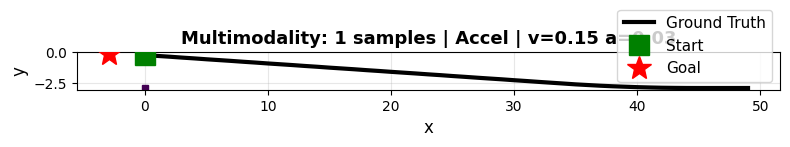

In [11]:
N_MULTI = 1  # generate 1 sample for a single context
pick = 0      # which eval sample to use

single_ctx = eval_contexts[pick:pick+1]
multi_samples, _ = sample_trajectories(diffusion, single_ctx, n_samples_per=N_MULTI)
# multi_samples: (N_MULTI, 50, 2)

fig, ax = plt.subplots(figsize=(8, 8))
cmap = plt.cm.viridis

for s in range(N_MULTI):
    traj = multi_samples[s]
    color = cmap(s / N_MULTI)
    ax.plot(traj[:, 0], alpha=0.5, linewidth=1.2, color=color)
    ax.plot(traj[0, 0], 'o', color=color, markersize=4)
    ax.plot(traj[-1, 0], 's', color=color, markersize=4)

# Ground truth
gt = eval_gt[pick]
ax.plot(gt[:, 0], 'k-', linewidth=3, label='Ground Truth')

ctx = single_ctx.numpy()[0]
ax.plot(ctx[7], ctx[8], 'gs', markersize=14, zorder=5, label='Start')
ax.plot(ctx[0], ctx[1], 'r*', markersize=18, zorder=5, label='Goal')

part_names = ['Accel', 'Const', 'Decel']
part_idx = np.argmax(ctx[4:7])
ax.set_title(f"Multimodality: {N_MULTI} samples | {part_names[part_idx]} | v={ctx[2]:.2f} a={ctx[3]:.2f}",
             fontsize=13, fontweight='bold')
ax.set_xlabel("x", fontsize=12)
ax.set_ylabel("y", fontsize=12)
ax.set_aspect('equal')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Plot: Sampling Speed vs Quality (N steps)

Test how many Euler steps are needed for good quality (like Fig. 4b in the paper).

  N=  1 steps | ADE=0.0528 | Time=0.02s
  N=  2 steps | ADE=0.0418 | Time=0.01s
  N=  5 steps | ADE=0.0304 | Time=0.02s
  N= 10 steps | ADE=0.0413 | Time=0.03s
  N= 25 steps | ADE=0.0423 | Time=0.09s
  N= 50 steps | ADE=0.0583 | Time=0.17s
  N=100 steps | ADE=0.0396 | Time=0.33s


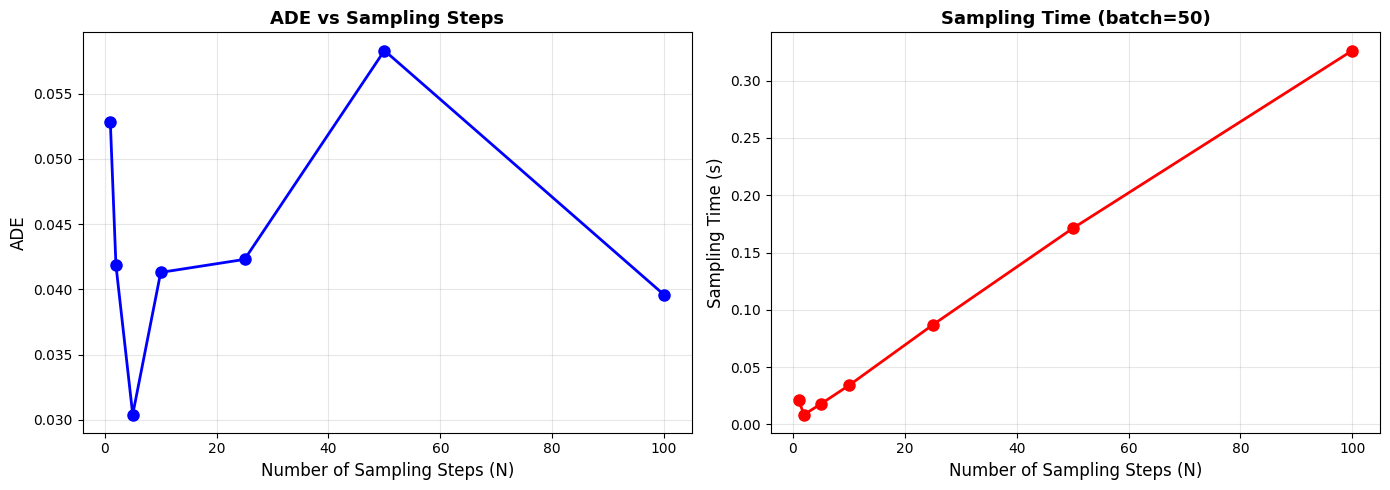

In [12]:
import time

step_counts = [1, 2, 5, 10, 25, 50, 100]
ade_by_steps = []
times_by_steps = []

# Use a small batch for speed test
speed_ctx = eval_contexts[:50]
speed_gt = eval_gt[:50]

for n_steps in step_counts:
    diffusion.set_sampling_timesteps(n_steps)
    
    t0 = time.time()
    samp, _ = sample_trajectories(diffusion, speed_ctx, n_samples_per=1)
    elapsed = time.time() - t0
    
    ade = np.sqrt(((samp - speed_gt) ** 2).sum(axis=-1)).mean()
    ade_by_steps.append(ade)
    times_by_steps.append(elapsed)
    print(f"  N={n_steps:>3d} steps | ADE={ade:.4f} | Time={elapsed:.2f}s")

# Reset to default
diffusion.set_sampling_timesteps(N_SAMPLING_STEPS)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(step_counts, ade_by_steps, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel("Number of Sampling Steps (N)", fontsize=12)
ax1.set_ylabel("ADE", fontsize=12)
ax1.set_title("ADE vs Sampling Steps", fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)

ax2.plot(step_counts, times_by_steps, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel("Number of Sampling Steps (N)", fontsize=12)
ax2.set_ylabel("Sampling Time (s)", fontsize=12)
ax2.set_title(f"Sampling Time (batch={len(speed_ctx)})", fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11 Conclusion

In [13]:
@torch.no_grad()
def sample_trajectories(diffusion, contexts, n_samples_per=1):
    """
    Generate trajectories for given context vectors.
    
    Args:
        diffusion: trained CFM model
        contexts: (B, 9) context tensor
        n_samples_per: how many samples to generate per context
    Returns:
        samples: (B * n_samples_per, ORIGINAL_LEN, 2) numpy array
        contexts_repeated: (B * n_samples_per, 9) numpy array
    """
    diffusion.eval()
    
    # repeat contexts for multiple samples
    ctx = contexts.repeat_interleave(n_samples_per, dim=0).to(DEVICE)
    batch_size = ctx.shape[0]
    
    global_cond = {'hideouts': ctx}
    cond = [(np.array([]), np.array([]))] * batch_size
    
    samples = diffusion.conditional_sample(global_cond, cond)  # (B*n, HORIZON, 2)
    samples = samples.cpu().numpy()
    
    # trim padding back to original 50 steps
    samples = samples[:, :ORIGINAL_LEN, :]
    contexts_out = ctx.cpu().numpy()
    
    return samples, contexts_out

print("Sampling helper ready.")

Sampling helper ready.


In [14]:
# 1 second horizon, 25 steps => 0.04s per step
def trapezoidal_profile(v_max, a_max, total_dist, n_steps=50):
    """
    Generate trapezoidal/triangular velocity profile and integrated position profile.
    """
    if v_max <= 0 or a_max <= 0 or total_dist < 0 or n_steps < 2:
        raise ValueError("Expected v_max>0, a_max>0, total_dist>=0, n_steps>=2")

    t_accel_nominal = v_max / a_max
    d_accel_nominal = 0.5 * a_max * t_accel_nominal**2

    if 2 * d_accel_nominal >= total_dist:
        t_accel = np.sqrt(total_dist / a_max) if total_dist > 0 else 0.0
        v_peak = a_max * t_accel
        t_const = 0.0
    else:
        t_accel = t_accel_nominal
        v_peak = v_max
        t_const = (total_dist - 2 * d_accel_nominal) / v_max

    total_time = 2 * t_accel + t_const
    time_steps = np.linspace(0.0, total_time, n_steps)
    dt = np.diff(time_steps, prepend=time_steps[0])

    profile = np.zeros_like(time_steps)
    decel_start = t_accel + t_const
    for i, t in enumerate(time_steps):
        if t < t_accel_nominal:
            profile[i] = a_max * t
        elif t < decel_start:
            profile[i] = v_peak
        else:
            profile[i] = max(0.0, v_peak - a_max * (t - decel_start))

    position = np.cumsum(profile * dt)
    if position[-1] > 0 and total_dist > 0:
        position *= total_dist / position[-1]

    return profile, position

Test context shape: (1, 9)


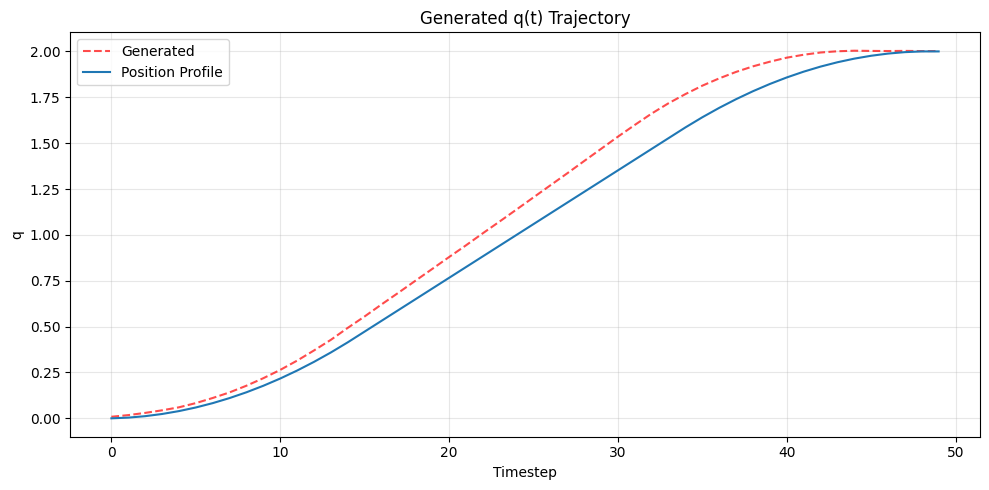

Mean Absolute Error: 0.0913


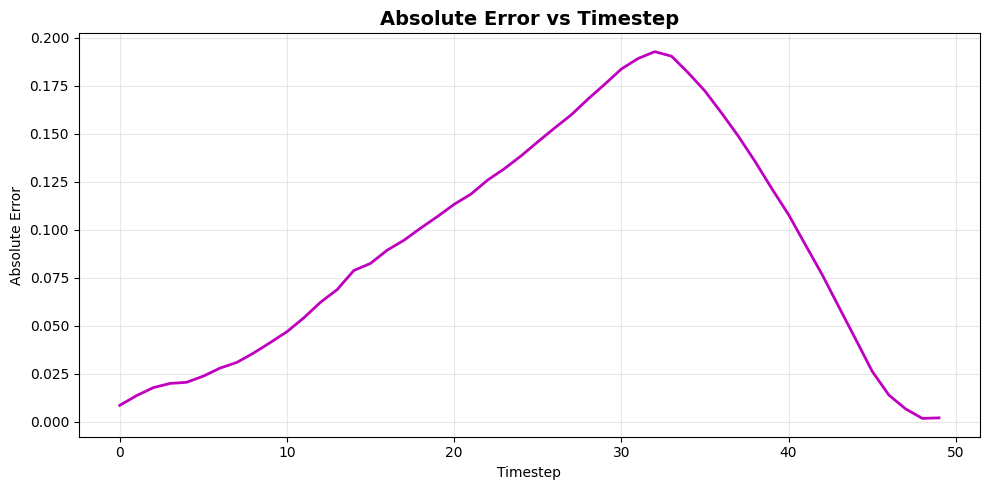

In [15]:
N_SAMPLES_PER = 1

# Context vector must match training format exactly:
# [s_goal, qdot_init, v_const, accel, part_0, part_1, part_2, part_3, q_init]  (9-dim)
# part_enum has 4 unique values (0=Accel, 1=Const, 2=Decel, 3=?)
# N_PARTS = 4
# s_goal   = 3.0
# q_init   = 0.0
# qdot_init = 0.0
# v_const  = 0.15
# accel    = 0.037
# part_enum = 0   # 0=Accel

# 1 - 5 m
# 0.1 - 0.2 m/s
# 0.02 - 0.04 m/s²

N_PARTS = 4
s_goal   = 2
v_const  = 0.156
accel    = 0.028
q_init   = 0.0
qdot_init = 0.0
part_enum = 0   # 0=Accel

vel, pos = trapezoidal_profile(v_max=v_const, a_max=accel, total_dist=s_goal)

part_onehot = np.zeros((1, N_PARTS))
part_onehot[0, part_enum] = 1.0

context_data = np.concatenate([
    np.array([[s_goal, qdot_init, v_const, accel]]),
    part_onehot,
    np.array([[q_init]])
], axis=1)  # shape (1, 9)

print(f"Test context shape: {context_data.shape}")  # should be (1, 9)

context = torch.tensor(context_data, dtype=torch.float32)
samples, _ = sample_trajectories(diffusion, context, n_samples_per=1)

# plot x(t)
plt.figure(figsize=(10, 5))
timesteps = np.arange(ORIGINAL_LEN)
for s in range(N_SAMPLES_PER):
    plt.plot(timesteps, samples[s, :, 0], 'r--', linewidth=1.5, alpha=0.7, label='Generated' if s == 0 else None)
plt.plot(pos, label='Position Profile')
plt.xlabel('Timestep')
plt.ylabel('q')
plt.title('Generated q(t) Trajectory')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# error vs profile
gen_traj = samples[0, :, 0]  # (50,)
error = np.abs(gen_traj - pos)

print(f"Mean Absolute Error: {error.mean():.4f}")
plt.figure(figsize=(10, 5))
plt.plot(timesteps, error, 'm-', linewidth=2)
plt.xlabel('Timestep')
plt.ylabel('Absolute Error')
plt.title('Absolute Error vs Timestep', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
# # # Pick test samples to evaluate
# # N_EVAL = 200          # how many test contexts to use
# # # N_SAMPLES_PER = 5     # how many trajectories to sample per context
# # N_SAMPLES_PER = 1     # how many trajectories to sample per context

# # rng = np.random.default_rng(42)
# # eval_idx = rng.choice(len(context_all), N_EVAL, replace=False)

# eval_contexts = context_all[eval_idx]
# eval_gt = A_gt[eval_idx]  # (N_EVAL, 50, 2)

# # Generate
# samples, _ = sample_trajectories(diffusion, eval_contexts, n_samples_per=N_SAMPLES_PER)
# # samples = samples.reshape(N_EVAL, N_SAMPLES_PER, ORIGINAL_LEN, 2)